<a href="https://colab.research.google.com/github/Tilly-11/Quantitative-finance-projects/blob/main/Portfolio_Optimization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pip install PyPortfolioOpt yfinance

In [ ]:
#Import the libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pypfopt.efficient_frontier import EfficientFrontier
from pypfopt.expected_returns import mean_historical_return
from pypfopt.risk_models import CovarianceShrinkage
from pypfopt.discrete_allocation import DiscreteAllocation, get_latest_prices
import yfinance as yf

In [ ]:
#Create Function to get the stock Data from a local file
def fetch_data(file_path):
  data = pd.read_csv(file_path, index_col='Date', parse_dates=True)
  return data

#Create Function to get the stock data from a stock site
def fetch_stock_data_from_site(tickers, start_date, end_date):
  data = yf.download(tickers, start=start_date, end=end_date)
  return data

In [ ]:
#Create function to Optimize the portfolio
def optimize_portfolio(data):
  #Calculating the annualized expected returns based on historical data
  mu = mean_historical_return(data)
  #Covariance matrix using Ledoit-colf shrinkage for robustness
  S = CovarianceShrinkage(data).ledoit_wolf()
  #Initialize the effiecient frontier object
  ef = EfficientFrontier(mu, S)
  #Get the weights for the optimized portfolio
  weights = ef.max_sharpe()
  #Clean the weights
  clean_weights = ef.clean_weights()
  #Get portfolio performance
  ef.portfolio_performance(verbose=True) # returns (expected return, volatility, Sharpe Ratio)

  sharpe_ratio = ef.portfolio_performance()[2]
  #Categorize the sharp Ratio
  if sharpe_ratio > 3.0:
    sharpe_evaluation = 'Exceptional'
  elif sharpe_ratio > 2.0:
    sharpe_evaluation = 'Excellent'
  elif sharpe_ratio > 1.0:
    sharpe_evaluation = 'Good'
  else:
    sharpe_evaluation = 'Suboptimal'

  print(f'\nSharpe Ration Evaluation: {sharpe_evaluation}')

  return clean_weights, mu, S

In [ ]:
#Create function to calculate DiscreteAllocations
def calculate_discrete_allocations(data, weights, total_portfolio_value):
  #fetching the latest price
  latest_prices = get_latest_prices(data)
  #Initializing the discrete allocation object with weights and portfolio value
  da = DiscreteAllocation(weights, latest_prices, total_portfolio_value=total_portfolio_value)
  #Calculate the number of shares to buy and the leftover
  allocation, leftover = da.lp_portfolio()

  return allocation, leftover, latest_prices

In [ ]:
#Create a function to visualize the results
def plot_results(weights):
  # Aggregate weights by ticker for plotting
  aggregated_weights = {}
  for (price_type, ticker), weight in weights.items():
    if ticker not in aggregated_weights:
      aggregated_weights[ticker] = 0
    aggregated_weights[ticker] += weight

  plt.figure(figsize=(10,6))
  plt.bar(aggregated_weights.keys(), aggregated_weights.values())
  plt.xlabel('Stocks')
  plt.ylabel('Weights')
  plt.title('Optimized Portfolio Weights')
  plt.show()

/tmp/ipykernel_1084/2975897962.py:8: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers, start=start_date, end=end_date)
[*********************100%***********************]  5 of 5 completed


Expected annual return: 47.5%
Annual volatility: 46.5%
Sharpe Ratio: 1.02

Sharpe Ration Evaluation: Good

Discrete allocation: {('Close', 'AAPL'): 57, ('Close', 'TSLA'): 162, ('High', 'AAPL'): 79, ('High', 'MSFT'): 12, ('High', 'TSLA'): 144, ('Low', 'AAPL'): 65, ('Low', 'MSFT'): 6, ('Low', 'TSLA'): 119, ('Open', 'AAPL'): 41, ('Open', 'TSLA'): 108}
Funds remaining: $35.61


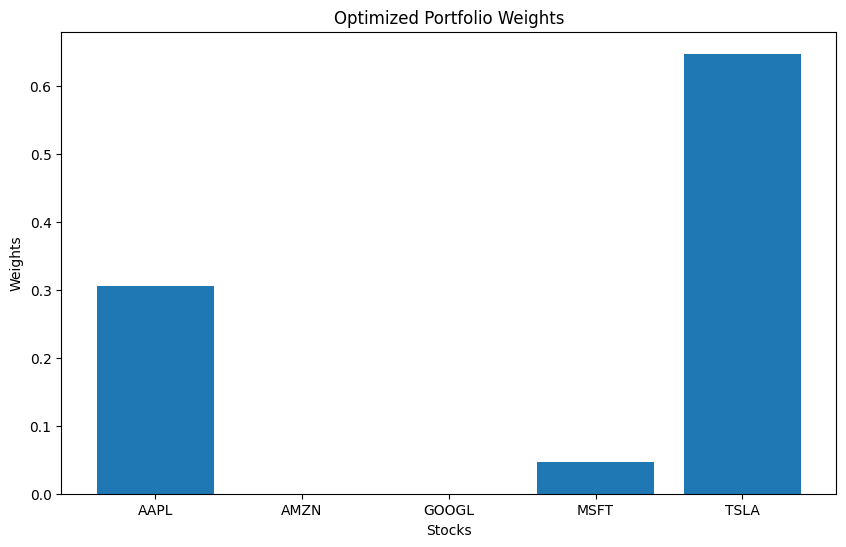

In [ ]:
#Execute Program
#Define stock tickers and date range
tickers = ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'TSLA'] # Example tickers
start_date = '2020-01-01'
end_date = '2023-01-01'

#Get the stock data from the stock site
data = fetch_stock_data_from_site(tickers, start_date, end_date)

#Optimize the portfolio
weights, mu, S = optimize_portfolio(data)

# Define total portfolio value for discrete allocation
total_portfolio_value = 100000

# Calculate discrete allocations
allocation, leftover, latest_prices = calculate_discrete_allocations(data, weights, total_portfolio_value)

print(f"\nDiscrete allocation: {allocation}")
print(f"Funds remaining: ${leftover:.2f}")

# Visualize the results
plot_results(weights)